In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor,cub
%env TENSORLY_BACKEND=cupy
import tensorly as tl
import plotly.io as pio
pio.renderers.default = 'iframe'
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()
print(f'TensorLy backend: {tl.get_backend()}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUPY_ACCELERATORS=cutensor,cub
env: TENSORLY_BACKEND=cupy
TensorLy backend: cupy


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from hoda.tensorize import fh_power, fh_log_envelope, hankel_tensor
from hoda.classification import ZLogRatio, ZScore
import numpy as np
import scipy.linalg
from hoda.tensorize import hankel_tensor
dataset = BNCI2014_008()

paradigm = P300(resample=48)
epochs, y, meta = paradigm.get_data(
     dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
X = epochs.get_data()
print(X.shape)
X = hankel_tensor(X, pad=False)
X = tl.tensor(X)
X.shape

/usr/local/share/venv/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>

/usr/local/share/venv/lib64/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning:

This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.



Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied
(4200, 8, 48)


/usr/local/share/venv/lib/python3.12/site-packages/moabb/paradigms/base.py:350: RuntimeWarning:

Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.



(4200, 8, 25, 23)

In [3]:
import plotly.express as px

px.imshow(tl.to_numpy(X.mean(axis=1)[0]))

In [4]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=512,
        tol=1e-6,
        shrinkage='lw',
        obj='tr',
        solver='lanczos',
        toeplitz=(1,2),
        taper=None,
        extra_train_info=False,
        verbose=True,
        theta=0.0,
        forward=True,
        refit_shrinkage=True,
)


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from hoda.cov import mode_scatter
plt.style.use('default')

%load_ext line_profiler
%lprun -f hoda.fit_backward hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])

Backward HODA model rank=(1, 1, 1):  82%|███████████████████████████████████████▍        | 421/512 [00:44<00:09,  9.55it/s]


Timer unit: 1e-09 s

Total time: 45.2869 s
File: /home/arne/Workspace/PhD/hoda-bci/src/hoda/hoda.py
Function: fit_backward at line 180

Line #      Hits         Time  Per Hit   % Time  Line Contents
   180                                               def fit_backward(
   181                                                   self,
   182                                                   X,
   183                                                   y,
   184                                                   X_centered=None,
   185                                                   means=None,
   186                                                   classes=None,
   187                                                   class_counts=None,
   188                                               ):
   189         1     547687.0 547687.0      0.0          X, y = validate(X, y)
   190                                           
   191                                                   # TODO: calcula

In [6]:
df

,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,7.863442e-01,0.000854,0.000908
1,1,2,2,7.504732e-01,0.001983,0.000160
2,1,3,3,7.432544e-01,0.001973,0.000134
3,2,1,4,5.988694e-01,0.000868,0.000337
4,2,2,5,1.823426e+00,0.003160,0.000099
...,...,...,...,...,...,...
1261,421,2,1262,6.475145e-07,0.011806,0.000050
1262,421,3,1263,1.053893e-06,0.003645,0.000094
1263,422,1,1264,2.013502e-08,0.000923,0.000016
1264,422,2,1265,6.125288e-07,0.011806,0.000050


In [7]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr')
    fig.show()


In [8]:
if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_rt')
    fig.show()


In [9]:
px.line(df, x='flip', y='update', log_y=True, color='mode')


In [10]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

In [11]:
px.line(df, x='flip', y='objective', log_y=True, color='mode')

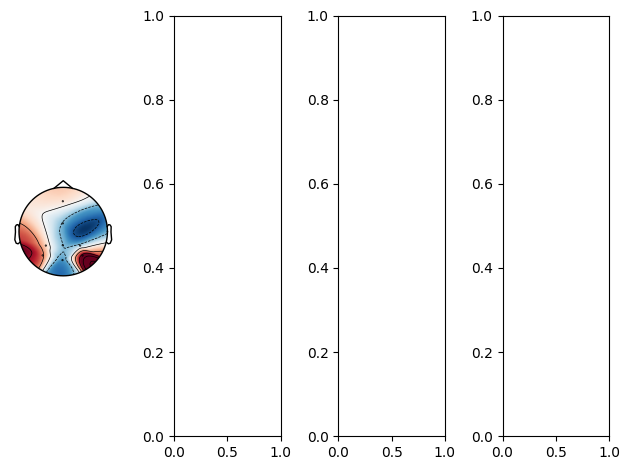

In [12]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

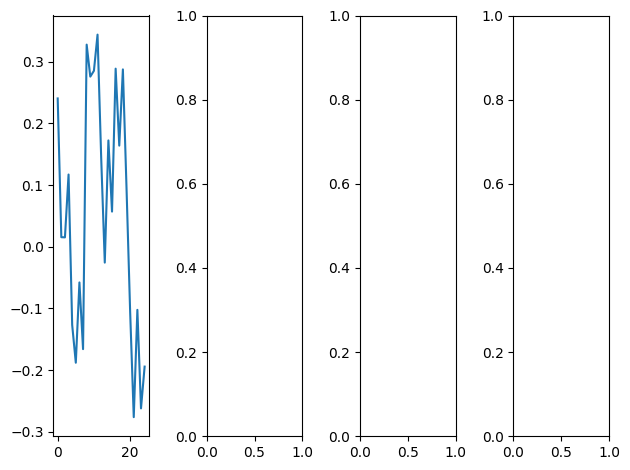

In [13]:
n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[1])))
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.weights_[1][:,i])
    axs.flatten()[i].plot(w)

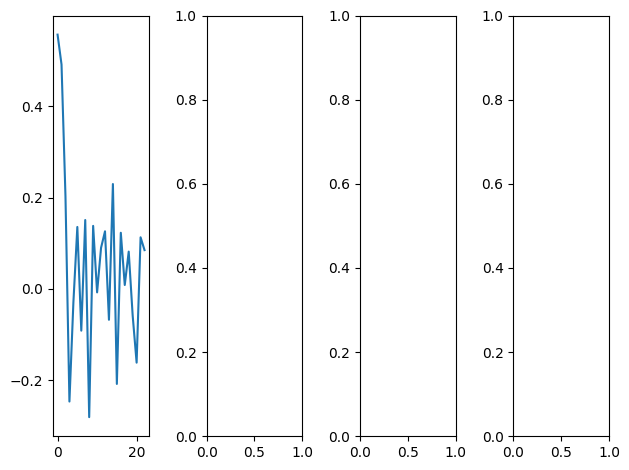

In [14]:
n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[2] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[2])))
for i in range(hoda.rank_[2]):
    w = tl.to_numpy(hoda.weights_[2][:,i])
    axs.flatten()[i].plot(w)

In [15]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model :  10%|██████▉                                                              | 51/511 [00:02<00:23, 19.68it/s]


,iteration,mode,flip,update
0,1,1,1,1.220027e+00
1,1,2,2,6.249559e-01
2,1,3,3,2.053692e+00
3,2,1,4,3.153678e-01
4,2,2,5,7.090565e-01
...,...,...,...,...
151,51,2,152,1.162458e-06
152,51,3,153,1.036795e-06
153,52,1,154,2.686225e-08
154,52,2,155,9.338586e-07


In [16]:
if hoda.extra_train_info:
    px.line(df, x='flip', y='mse', log_y=True)

In [17]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

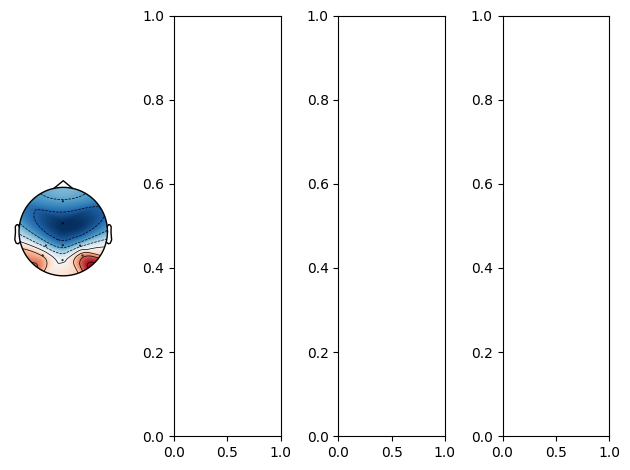

In [18]:
n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.aps_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.aps_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

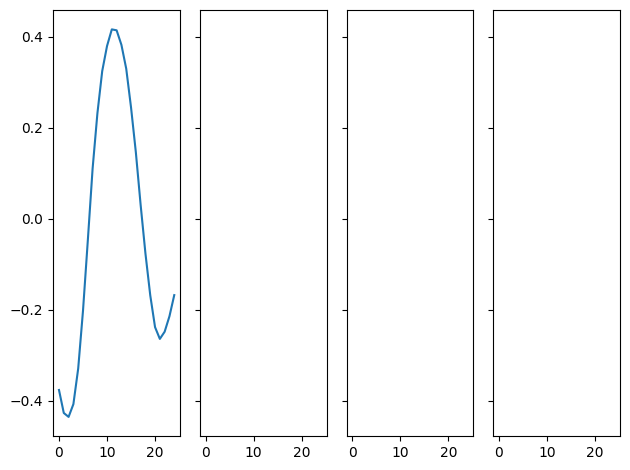

In [19]:
n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight', sharex=True, sharey=True)
vmax = float(tl.max(tl.abs(hoda.aps_[1])))
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.aps_[1][:,i])
    axs.flatten()[i].plot(w)

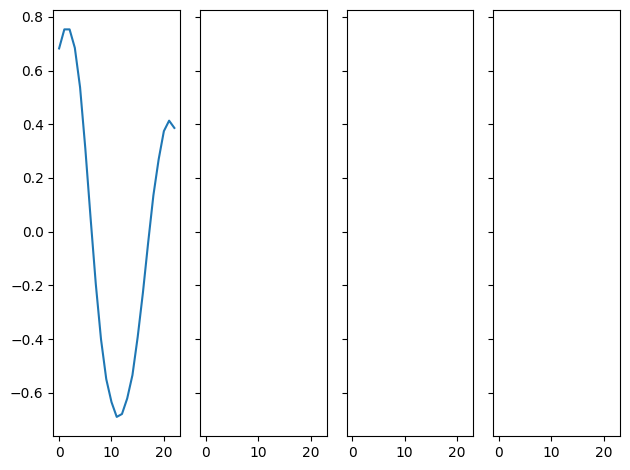

In [20]:
n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[2] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight', sharex=True, sharey=True)
vmax = float(tl.max(tl.abs(hoda.aps_[2])))
for i in range(hoda.rank_[2]):
    w = tl.to_numpy(hoda.aps_[2][:,i])
    axs.flatten()[i].plot(w)

In [21]:
from sklearn.feature_selection import SelectFpr, SelectFwe, SelectFdr
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

F, p = f_classif(xt, y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': F,
    'p': p,
    'select': F > 1
})
fig = px.bar(df, x='feature', y='F', color='select', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [22]:
from sklearn.decomposition import PCA

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))
xt = PCA(whiten=True).fit_transform(xt)

F, p = f_classif(xt, y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': F,
    'p': p,
    'select': F > 1
})
fig = px.bar(df, x='feature', y='F', color='select', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [23]:
from sklearn.manifold import TSNE

x_viz = TSNE(n_components=2).fit_transform(xt)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_layout(width=1000, height=800)
fig

ValueError: n_components=2 must be between 1 and min(n_samples, n_features)=1 with svd_solver='randomized'